
# Konux Case Study – Combined, Clean End-to-End Notebook  
**Vertical acceleration signals (2 kHz) – Train passage analysis**

This notebook combines the full workflow into one clean submission:
1. Load binary acceleration signals (`float32`) + parse filename metadata  
2. Raw data inspection (single plots, overlays, scan-all)  
3. Preprocessing (mean removal + band-pass filtering with zero-phase `filtfilt`)  
4. RMS envelope + automatic passage segmentation (train present vs. silence)  
5. Frequency-domain inspection (FFT spectrum)  
6. Feature extraction (time + frequency features + duration proxies)  
7. Feature visualization (distributions, correlations)  
8. Clustering (KMeans for 2 passages) + PCA visualization + cluster summaries  
9. Interpretation notes + limitations (as required by the case study)

> **Important:** High peaks are not treated as outliers; they are physical wheel–rail impact events.


In [35]:

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.fft import rfft, rfftfreq

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

FS = 2000  # Hz (given)
DATA_DIR = Path("/home/mamunds/job/pyspark/konux/data")  # put your .dat/.bin files here


## 1) Helper functions

In [36]:

def load_binary_signal(filepath: Path) -> np.ndarray:
    # Load raw float32 samples from .dat/.bin file.
    return np.fromfile(filepath, dtype=np.float32)


def parse_filename_metadata(filename: str) -> dict:
    # Parse metadata from:
    # <yyyymmdd>_<HHMMSS>_<sensor-id>_<deployment-id>_channel<channel-id>.<ext>
    meta = {
        "date": None,
        "time": None,
        "sensor_id": None,
        "deployment_id": None,
        "channel_id": None,
    }
    m = re.match(
        r"(?P<date>\d{8})_(?P<time>\d{6})_(?P<sensor>\d+)_(?P<deploy>\d+)_channel(?P<ch>\d+)\.(dat|bin)$",
        filename,
    )
    if m:
        meta["date"] = m.group("date")
        meta["time"] = m.group("time")
        meta["sensor_id"] = m.group("sensor")
        meta["deployment_id"] = m.group("deploy")
        meta["channel_id"] = m.group("ch")
    return meta


def bandpass_filter_zero_phase(x: np.ndarray, fs: int, low_hz=5.0, high_hz=500.0, order=4) -> np.ndarray:
    # Zero-phase Butterworth band-pass filter + DC removal.
    x = x - np.mean(x)
    nyq = fs / 2
    b, a = signal.butter(order, [low_hz / nyq, high_hz / nyq], btype="band")
    return signal.filtfilt(b, a, x)


def rms_envelope(x: np.ndarray, fs: int, window_s: float = 0.05) -> np.ndarray:
    # Sliding RMS envelope (energy proxy). window_s=0.05 -> 50 ms by default.
    w = max(1, int(window_s * fs))
    kernel = np.ones(w) / w
    return np.sqrt(np.convolve(x**2, kernel, mode="same"))


def segment_active_region(rms_env: np.ndarray, fs: int, pad_s: float = 0.10):
    # Segment active train passage using RMS envelope thresholding.
    # Baseline from first 10% (or at least 0.5 s).
    # Threshold = baseline_mean + 3 * baseline_std (heuristic).
    n = len(rms_env)
    baseline_n = min(n, max(int(0.5 * fs), int(0.1 * n)))
    baseline = rms_env[:baseline_n]
    thr = float(np.mean(baseline) + 3.0 * np.std(baseline))

    active = rms_env > thr
    if not np.any(active):
        return 0, n, np.ones(n, dtype=bool), thr

    idx = np.where(active)[0]
    start, end = int(idx[0]), int(idx[-1])
    pad = int(pad_s * fs)
    start = max(0, start - pad)
    end = min(n, end + pad)

    mask = np.zeros(n, dtype=bool)
    mask[start:end] = True
    return start, end, mask, thr


def extract_time_features(x: np.ndarray, fs: int) -> dict:
    feats = {}
    feats["rms"] = float(np.sqrt(np.mean(x**2)))
    feats["peak_to_peak"] = float(np.max(x) - np.min(x))
    feats["variance"] = float(np.var(x))
    feats["duration_s"] = float(len(x) / fs)

    peaks, _ = signal.find_peaks(np.abs(x), height=np.std(x))
    feats["num_peaks"] = int(len(peaks))

    if len(peaks) > 1:
        intervals = np.diff(peaks) / fs
        feats["mean_peak_interval_s"] = float(np.mean(intervals))
        feats["std_peak_interval_s"] = float(np.std(intervals))
    else:
        feats["mean_peak_interval_s"] = np.nan
        feats["std_peak_interval_s"] = np.nan

    return feats


def extract_frequency_features(x: np.ndarray, fs: int, fmax: float = 500.0) -> dict:
    yf = np.abs(rfft(x))
    xf = rfftfreq(len(x), 1 / fs)

    m = xf <= fmax
    xf2, yf2 = xf[m], yf[m]

    if np.sum(yf2) == 0:
        return {
            "dominant_frequency_hz": np.nan,
            "spectral_centroid_hz": np.nan,
            "energy_5_50": np.nan,
            "energy_50_200": np.nan,
            "energy_200_500": np.nan,
        }

    dom = float(xf2[np.argmax(yf2)])
    centroid = float(np.sum(xf2 * yf2) / np.sum(yf2))

    def band_energy(f_lo, f_hi):
        mm = (xf2 >= f_lo) & (xf2 < f_hi)
        return float(np.sum(yf2[mm] ** 2))

    return {
        "dominant_frequency_hz": dom,
        "spectral_centroid_hz": centroid,
        "energy_5_50": band_energy(5, 50),
        "energy_50_200": band_energy(50, 200),
        "energy_200_500": band_energy(200, 500),
    }


## 2) Load data + metadata table

In [37]:

if not DATA_DIR.exists():
    raise FileNotFoundError(f"DATA_DIR '{DATA_DIR}' not found. Create it and add your .dat/.bin files.")

files = sorted(list(DATA_DIR.glob("*.dat")) + list(DATA_DIR.glob("*.bin")))
if len(files) == 0:
    raise FileNotFoundError(f"No .dat or .bin files found in {DATA_DIR.resolve()}")

signals = {}
rows = []
for fp in files:
    x = load_binary_signal(fp)
    signals[fp.name] = x
    meta = parse_filename_metadata(fp.name)
    rows.append({"file": fp.name, **meta, "n_samples": len(x), "duration_s": len(x)/FS})

meta_df = pd.DataFrame(rows).set_index("file").sort_values(["date", "time", "sensor_id"])
meta_df


,date,time,sensor_id,deployment_id,channel_id,n_samples,duration_s
file,,,,,,,
20220507_131544_065205_001_channel1.bin,20220507,131544,065205,001,1,16000,8.0
20220507_131853_065205_001_channel1.bin,20220507,131853,065205,001,1,14000,7.0
20220509_091022_031264_001_channel1.bin,20220509,091022,031264,001,1,34000,17.0
20220509_094934_031264_001_channel1.bin,20220509,094934,031264,001,1,28000,14.0
20220509_095320_031157_001_channel1.bin,20220509,095320,031157,001,1,50000,25.0
20220509_100254_031157_001_channel1.bin,20220509,100254,031157,001,1,52000,26.0
20220509_104538_095913_001_channel1.bin,20220509,104538,095913,001,1,44000,22.0
20220509_105854_095913_001_channel1.bin,20220509,105854,095913,001,1,40000,20.0
20220511_110903_077531_001_channel1.bin,20220511,110903,077531,001,1,24000,12.0


## 3) Raw data visualization

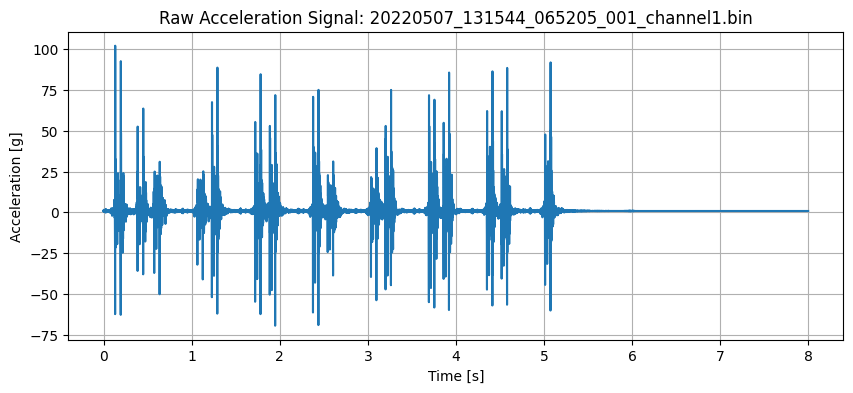

In [38]:

example_file = meta_df.index[0]
x_raw = signals[example_file]
t = np.arange(len(x_raw)) / FS

plt.figure(figsize=(10,4))
plt.plot(t, x_raw)
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.title(f"Raw Acceleration Signal: {example_file}")
plt.grid(True)
plt.show()


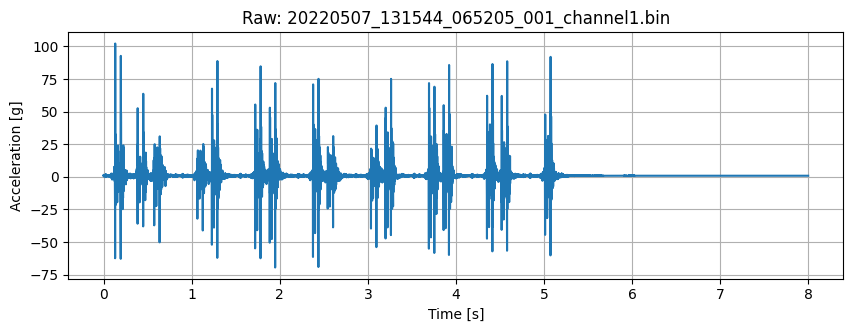

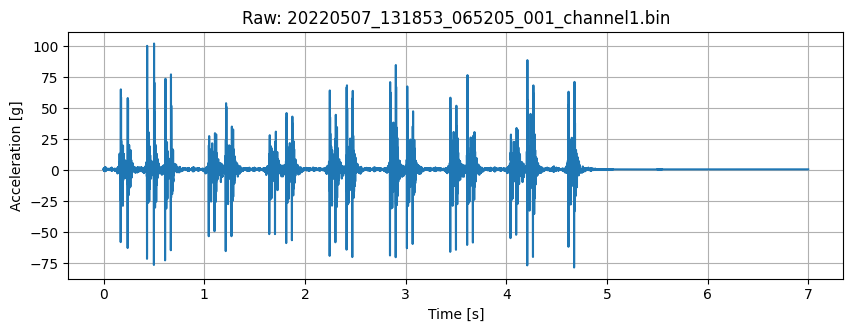

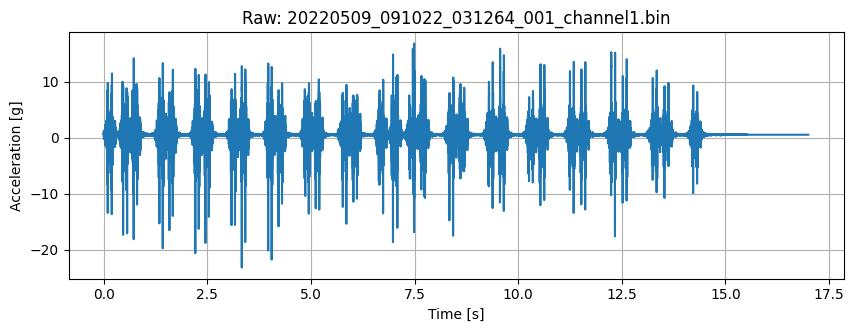

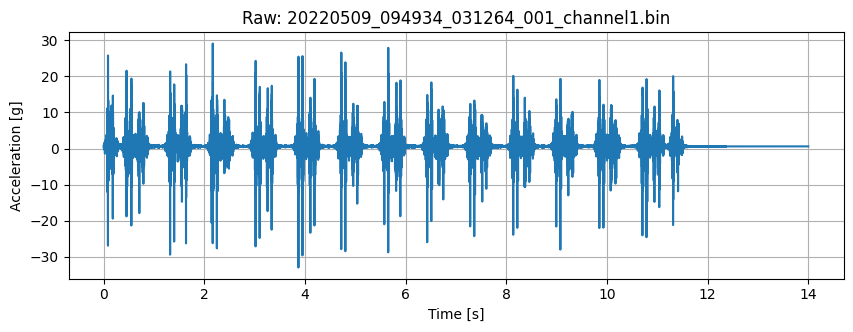

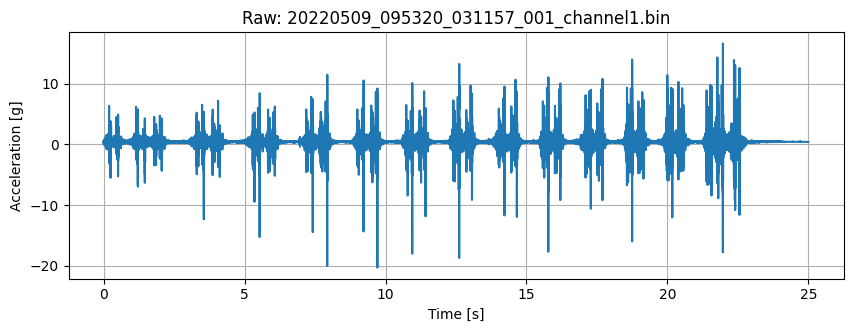

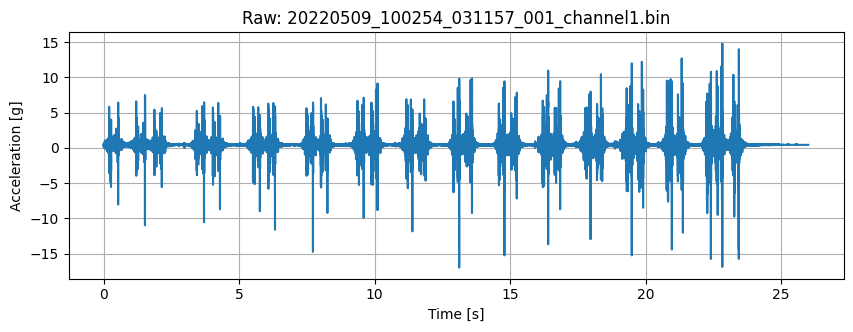

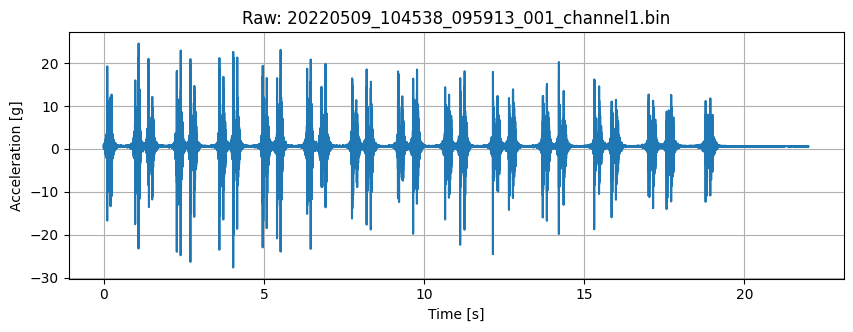

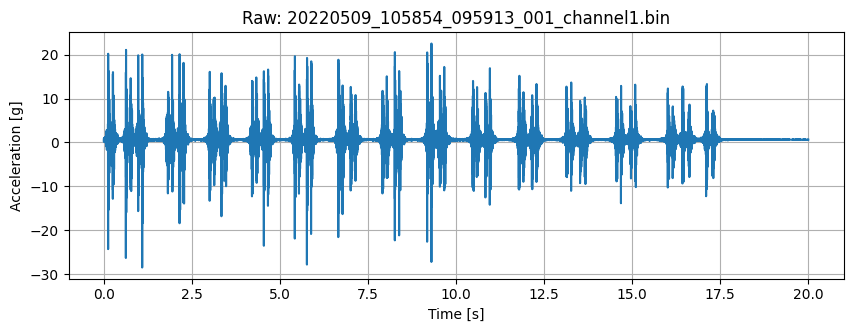

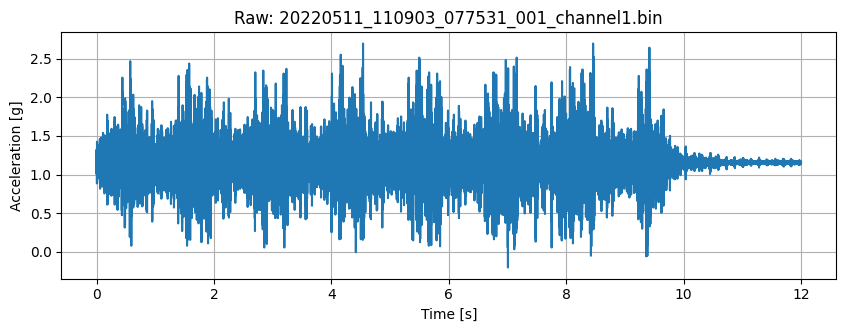

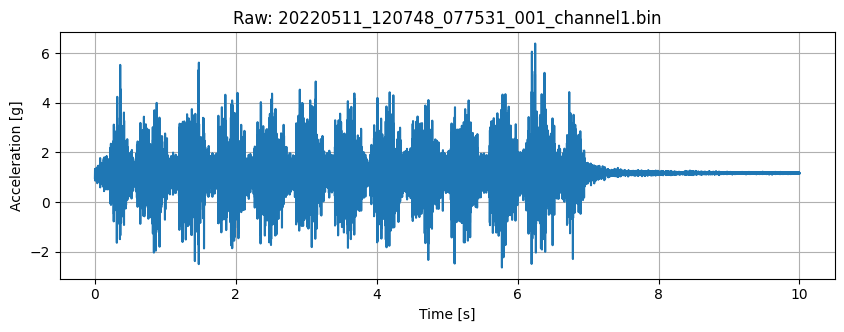

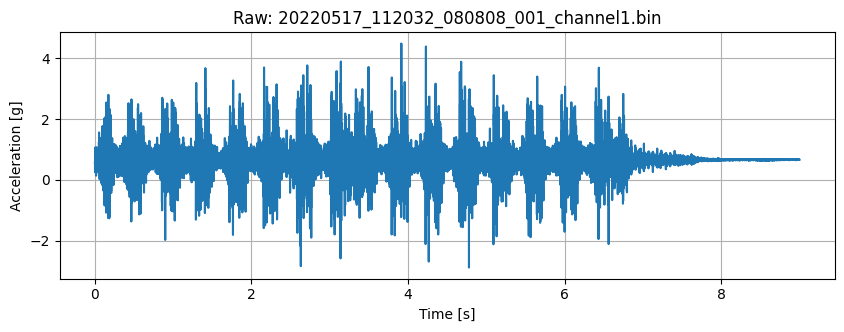

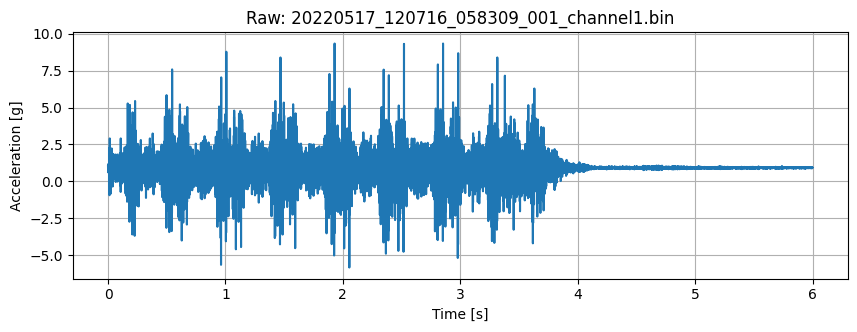

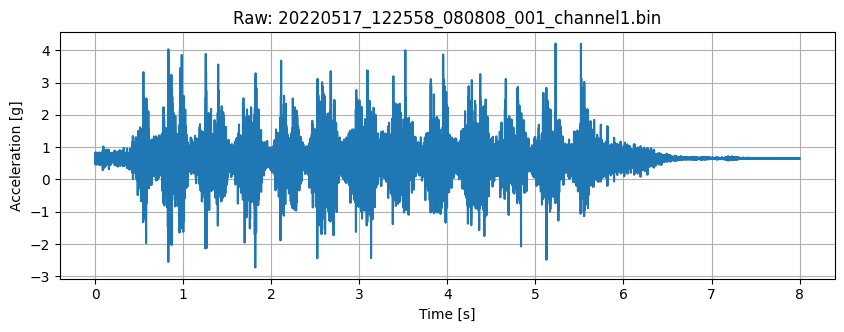

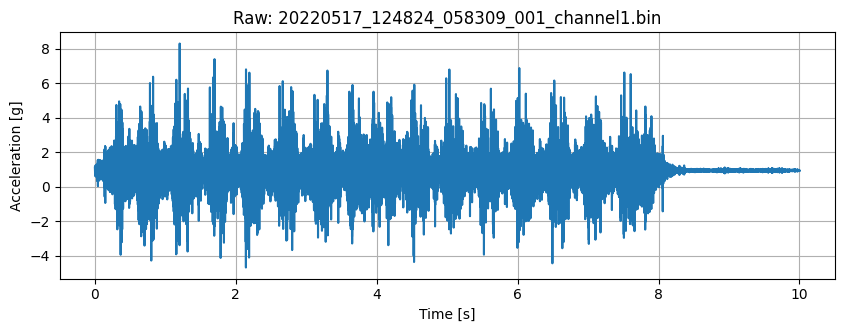

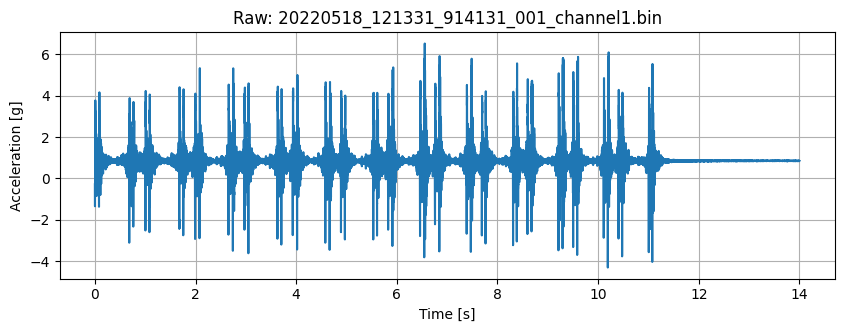

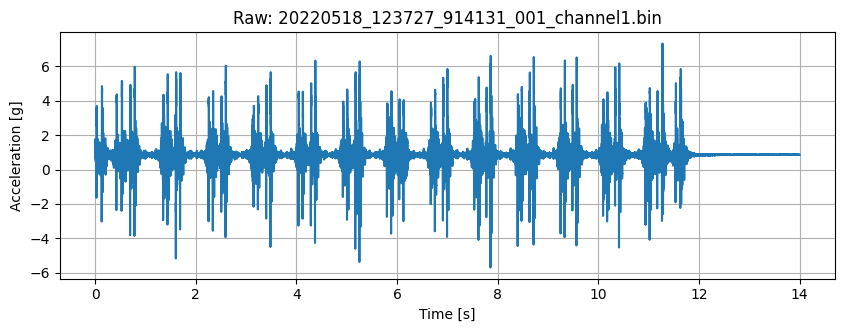

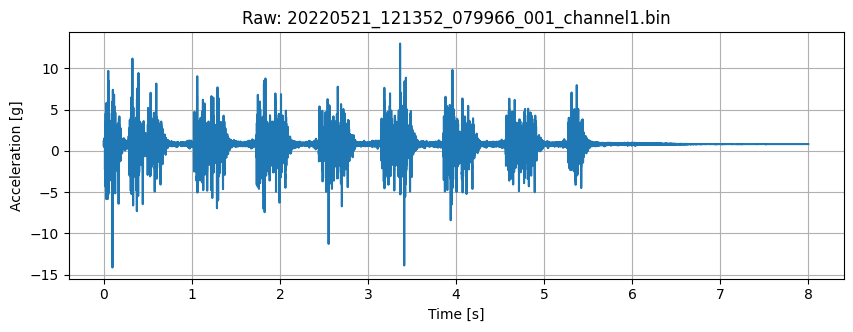

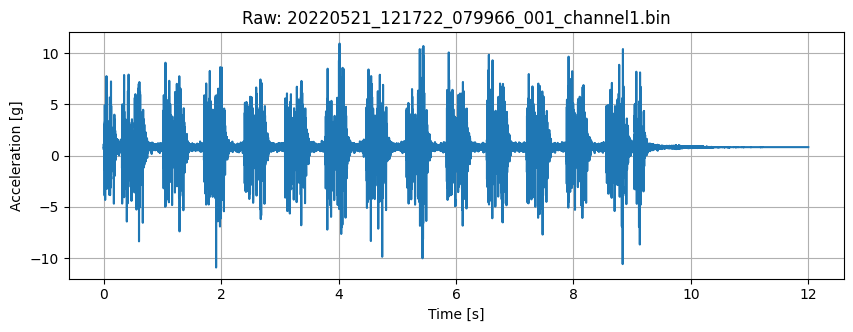

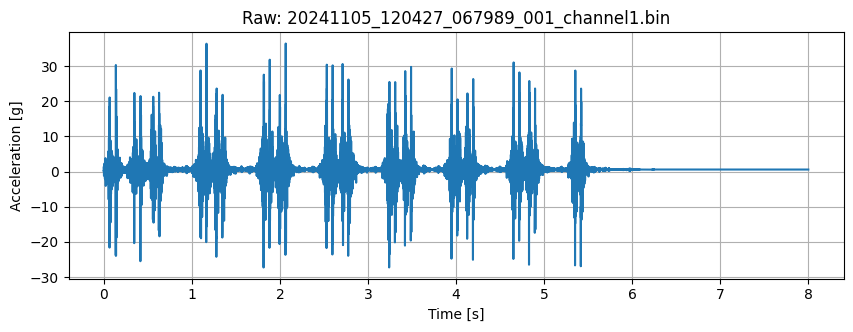

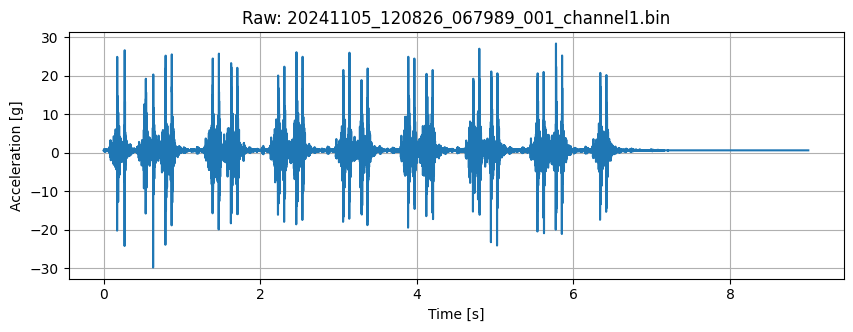

In [39]:

# Scan all raw signals (one plot per file)
for fname in meta_df.index:
    x = signals[fname]
    t = np.arange(len(x)) / FS
    plt.figure(figsize=(10,3.2))
    plt.plot(t, x)
    plt.xlabel("Time [s]")
    plt.ylabel("Acceleration [g]")
    plt.title(f"Raw: {fname}")
    plt.grid(True)
    plt.show()


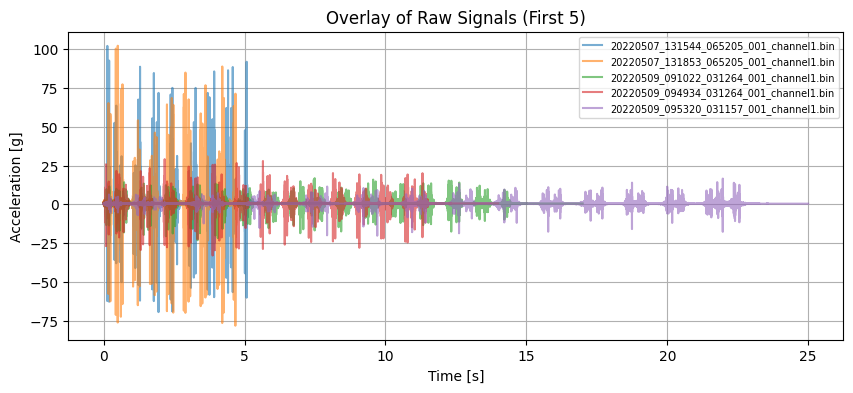

In [41]:

# Overlay first 5 raw signals
plt.figure(figsize=(10,4))
for fname in meta_df.index[:5]:
    x = signals[fname]
    t = np.arange(len(x)) / FS
    plt.plot(t, x, alpha=0.6, label=fname)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.title("Overlay of Raw Signals (First 5)")
plt.legend(fontsize=7)
plt.grid(True)
plt.show()


## 4) Preprocessing + RMS envelope + segmentation

In [42]:

signals_filt = {}
rms_envs = {}
segments = []

for fname in meta_df.index:
    x = signals[fname]
    xf = bandpass_filter_zero_phase(x, FS, low_hz=5, high_hz=500, order=4)
    signals_filt[fname] = xf

    env = rms_envelope(xf, FS, window_s=0.05)
    rms_envs[fname] = env

    s, e, mask, thr = segment_active_region(env, FS, pad_s=0.10)
    segments.append({"file": fname, "seg_start": s, "seg_end": e, "rms_threshold": thr})

segments_df = pd.DataFrame(segments).set_index("file")
segments_df


,seg_start,seg_end,rms_threshold
file,,,
20220507_131544_065205_001_channel1.bin,0,16000,21.447758
20220507_131853_065205_001_channel1.bin,0,14000,27.915071
20220509_091022_031264_001_channel1.bin,0,34000,5.405846
20220509_094934_031264_001_channel1.bin,0,28000,6.924471
20220509_095320_031157_001_channel1.bin,6367,45353,1.698446
20220509_100254_031157_001_channel1.bin,7156,47122,1.819381
20220509_104538_095913_001_channel1.bin,1989,11292,5.068180
20220509_105854_095913_001_channel1.bin,0,40000,6.328831
20220511_110903_077531_001_channel1.bin,2855,19012,0.418737


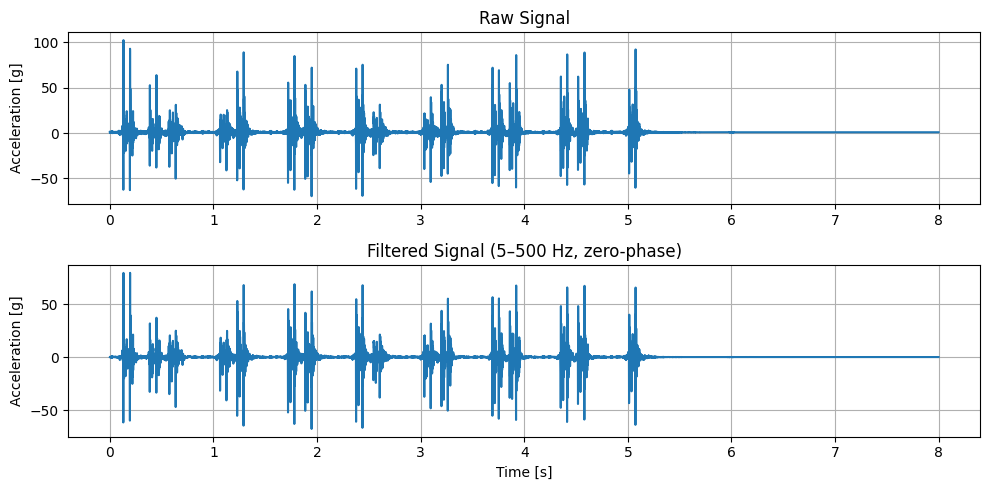

In [43]:

# Raw vs filtered (robust to length mismatches)
example_file = meta_df.index[0]
x_raw = signals[example_file]
x_filt = signals_filt[example_file]

n = min(len(x_raw), len(x_filt))
t = np.arange(n) / FS

plt.figure(figsize=(10,5))

plt.subplot(2,1,1)
plt.plot(t, x_raw[:n])
plt.title("Raw Signal")
plt.ylabel("Acceleration [g]")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(t, x_filt[:n])
plt.title("Filtered Signal (5–500 Hz, zero-phase)")
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.grid(True)

plt.tight_layout()
plt.show()


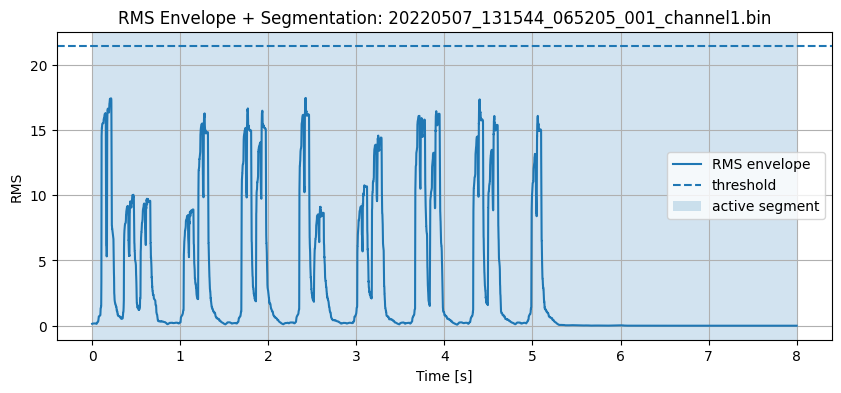

In [44]:

# RMS envelope + segmentation visualization
example_file = meta_df.index[0]
env = rms_envs[example_file]

s = int(segments_df.loc[example_file, "seg_start"])
e = int(segments_df.loc[example_file, "seg_end"])
thr = float(segments_df.loc[example_file, "rms_threshold"])

t = np.arange(len(env)) / FS

plt.figure(figsize=(10,4))
plt.plot(t, env, label="RMS envelope")
plt.axhline(thr, linestyle="--", label="threshold")
plt.axvspan(s/FS, e/FS, alpha=0.2, label="active segment")
plt.xlabel("Time [s]")
plt.ylabel("RMS")
plt.title(f"RMS Envelope + Segmentation: {example_file}")
plt.legend()
plt.grid(True)
plt.show()


## 5) Frequency spectrum (FFT) on segmented signal

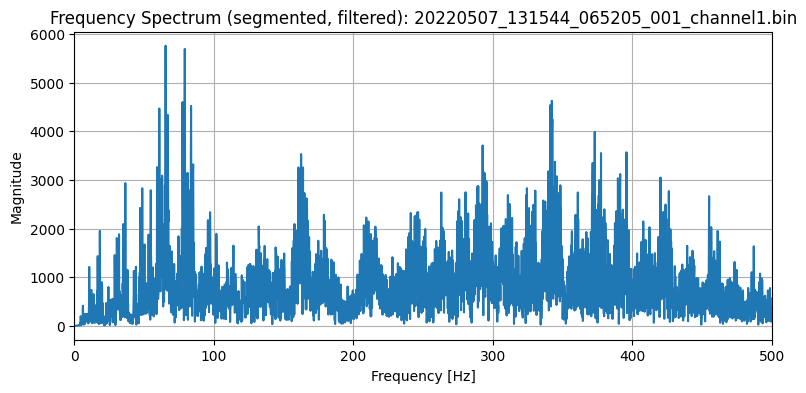

In [45]:

example_file = meta_df.index[0]
xf = signals_filt[example_file]
s = int(segments_df.loc[example_file, "seg_start"])
e = int(segments_df.loc[example_file, "seg_end"])

xseg = xf[s:e]
yf = np.abs(rfft(xseg))
freq = rfftfreq(len(xseg), 1/FS)

plt.figure(figsize=(9,4))
plt.plot(freq, yf)
plt.xlim(0, 500)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title(f"Frequency Spectrum (segmented, filtered): {example_file}")
plt.grid(True)
plt.show()


## 6) Feature extraction (on segmented, filtered signals)

In [46]:

feature_rows = []
for fname in meta_df.index:
    xf = signals_filt[fname]
    s = int(segments_df.loc[fname, "seg_start"])
    e = int(segments_df.loc[fname, "seg_end"])
    xseg = xf[s:e]

    feats = {}
    feats.update(parse_filename_metadata(fname))
    feats.update(extract_time_features(xseg, FS))
    feats.update(extract_frequency_features(xseg, FS, fmax=500.0))
    feats["active_duration_s"] = float((e - s) / FS)

    feats["file"] = fname
    feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows).set_index("file")
features_df


,date,time,sensor_id,deployment_id,channel_id,rms,peak_to_peak,variance,duration_s,num_peaks,mean_peak_interval_s,std_peak_interval_s,dominant_frequency_hz,spectral_centroid_hz,energy_5_50,energy_50_200,energy_200_500,active_duration_s
file,,,,,,,,,,,,,,,,,,
20220507_131544_065205_001_channel1.bin,20220507,131544,065205,001,1,6.119571,147.311505,37.449145,8.0000,583,0.008562,0.043333,65.375000,258.771149,1.192286e+08,1.537899e+09,3.102159e+09,8.0000
20220507_131853_065205_001_channel1.bin,20220507,131853,065205,001,1,6.829386,153.924298,46.640509,7.0000,510,0.008943,0.040564,71.714286,258.922189,1.119752e+08,1.798520e+09,2.616725e+09,7.0000
20220509_091022_031264_001_channel1.bin,20220509,091022,031264,001,1,1.490862,33.531185,2.222669,17.0000,2027,0.007091,0.037174,195.058824,262.223712,1.485902e+07,5.798500e+08,6.831385e+08,17.0000
20220509_094934_031264_001_channel1.bin,20220509,094934,031264,001,1,2.118035,53.790225,4.486070,14.0000,1565,0.007301,0.035164,196.357143,279.335164,1.928475e+07,5.600017e+08,1.170643e+09,14.0000
20220509_095320_031157_001_channel1.bin,20220509,095320,031157,001,1,0.925324,26.486156,0.856225,19.4930,1658,0.011708,0.069307,130.970092,226.653659,2.690408e+07,4.262671e+08,1.799806e+08,19.4930
20220509_100254_031157_001_channel1.bin,20220509,100254,031157,001,1,0.868380,23.053479,0.754084,19.9830,1593,0.012512,0.074026,132.912976,231.093540,2.064158e+07,3.853006e+08,1.818711e+08,19.9830
20220509_104538_095913_001_channel1.bin,20220509,104538,095913,001,1,2.086196,41.248295,4.352214,4.6515,388,0.011859,0.069361,228.098463,266.630575,2.911735e+06,5.325739e+07,1.242400e+08,4.6515
20220509_105854_095913_001_channel1.bin,20220509,105854,095913,001,1,1.570273,44.038942,2.465756,20.0000,1716,0.010048,0.063863,153.950000,254.782127,5.241887e+07,7.823284e+08,1.058061e+09,20.0000
20220511_110903_077531_001_channel1.bin,20220511,110903,077531,001,1,0.279406,2.739692,0.078068,8.0785,2399,0.003368,0.004981,65.853809,275.438391,1.066886e+06,2.127692e+06,6.988531e+06,8.0785


Number of features in pair plot: 13
Feature names:
['rms', 'peak_to_peak', 'variance', 'duration_s', 'num_peaks', 'mean_peak_interval_s', 'std_peak_interval_s', 'dominant_frequency_hz', 'spectral_centroid_hz', 'energy_5_50', 'energy_50_200', 'energy_200_500', 'active_duration_s']


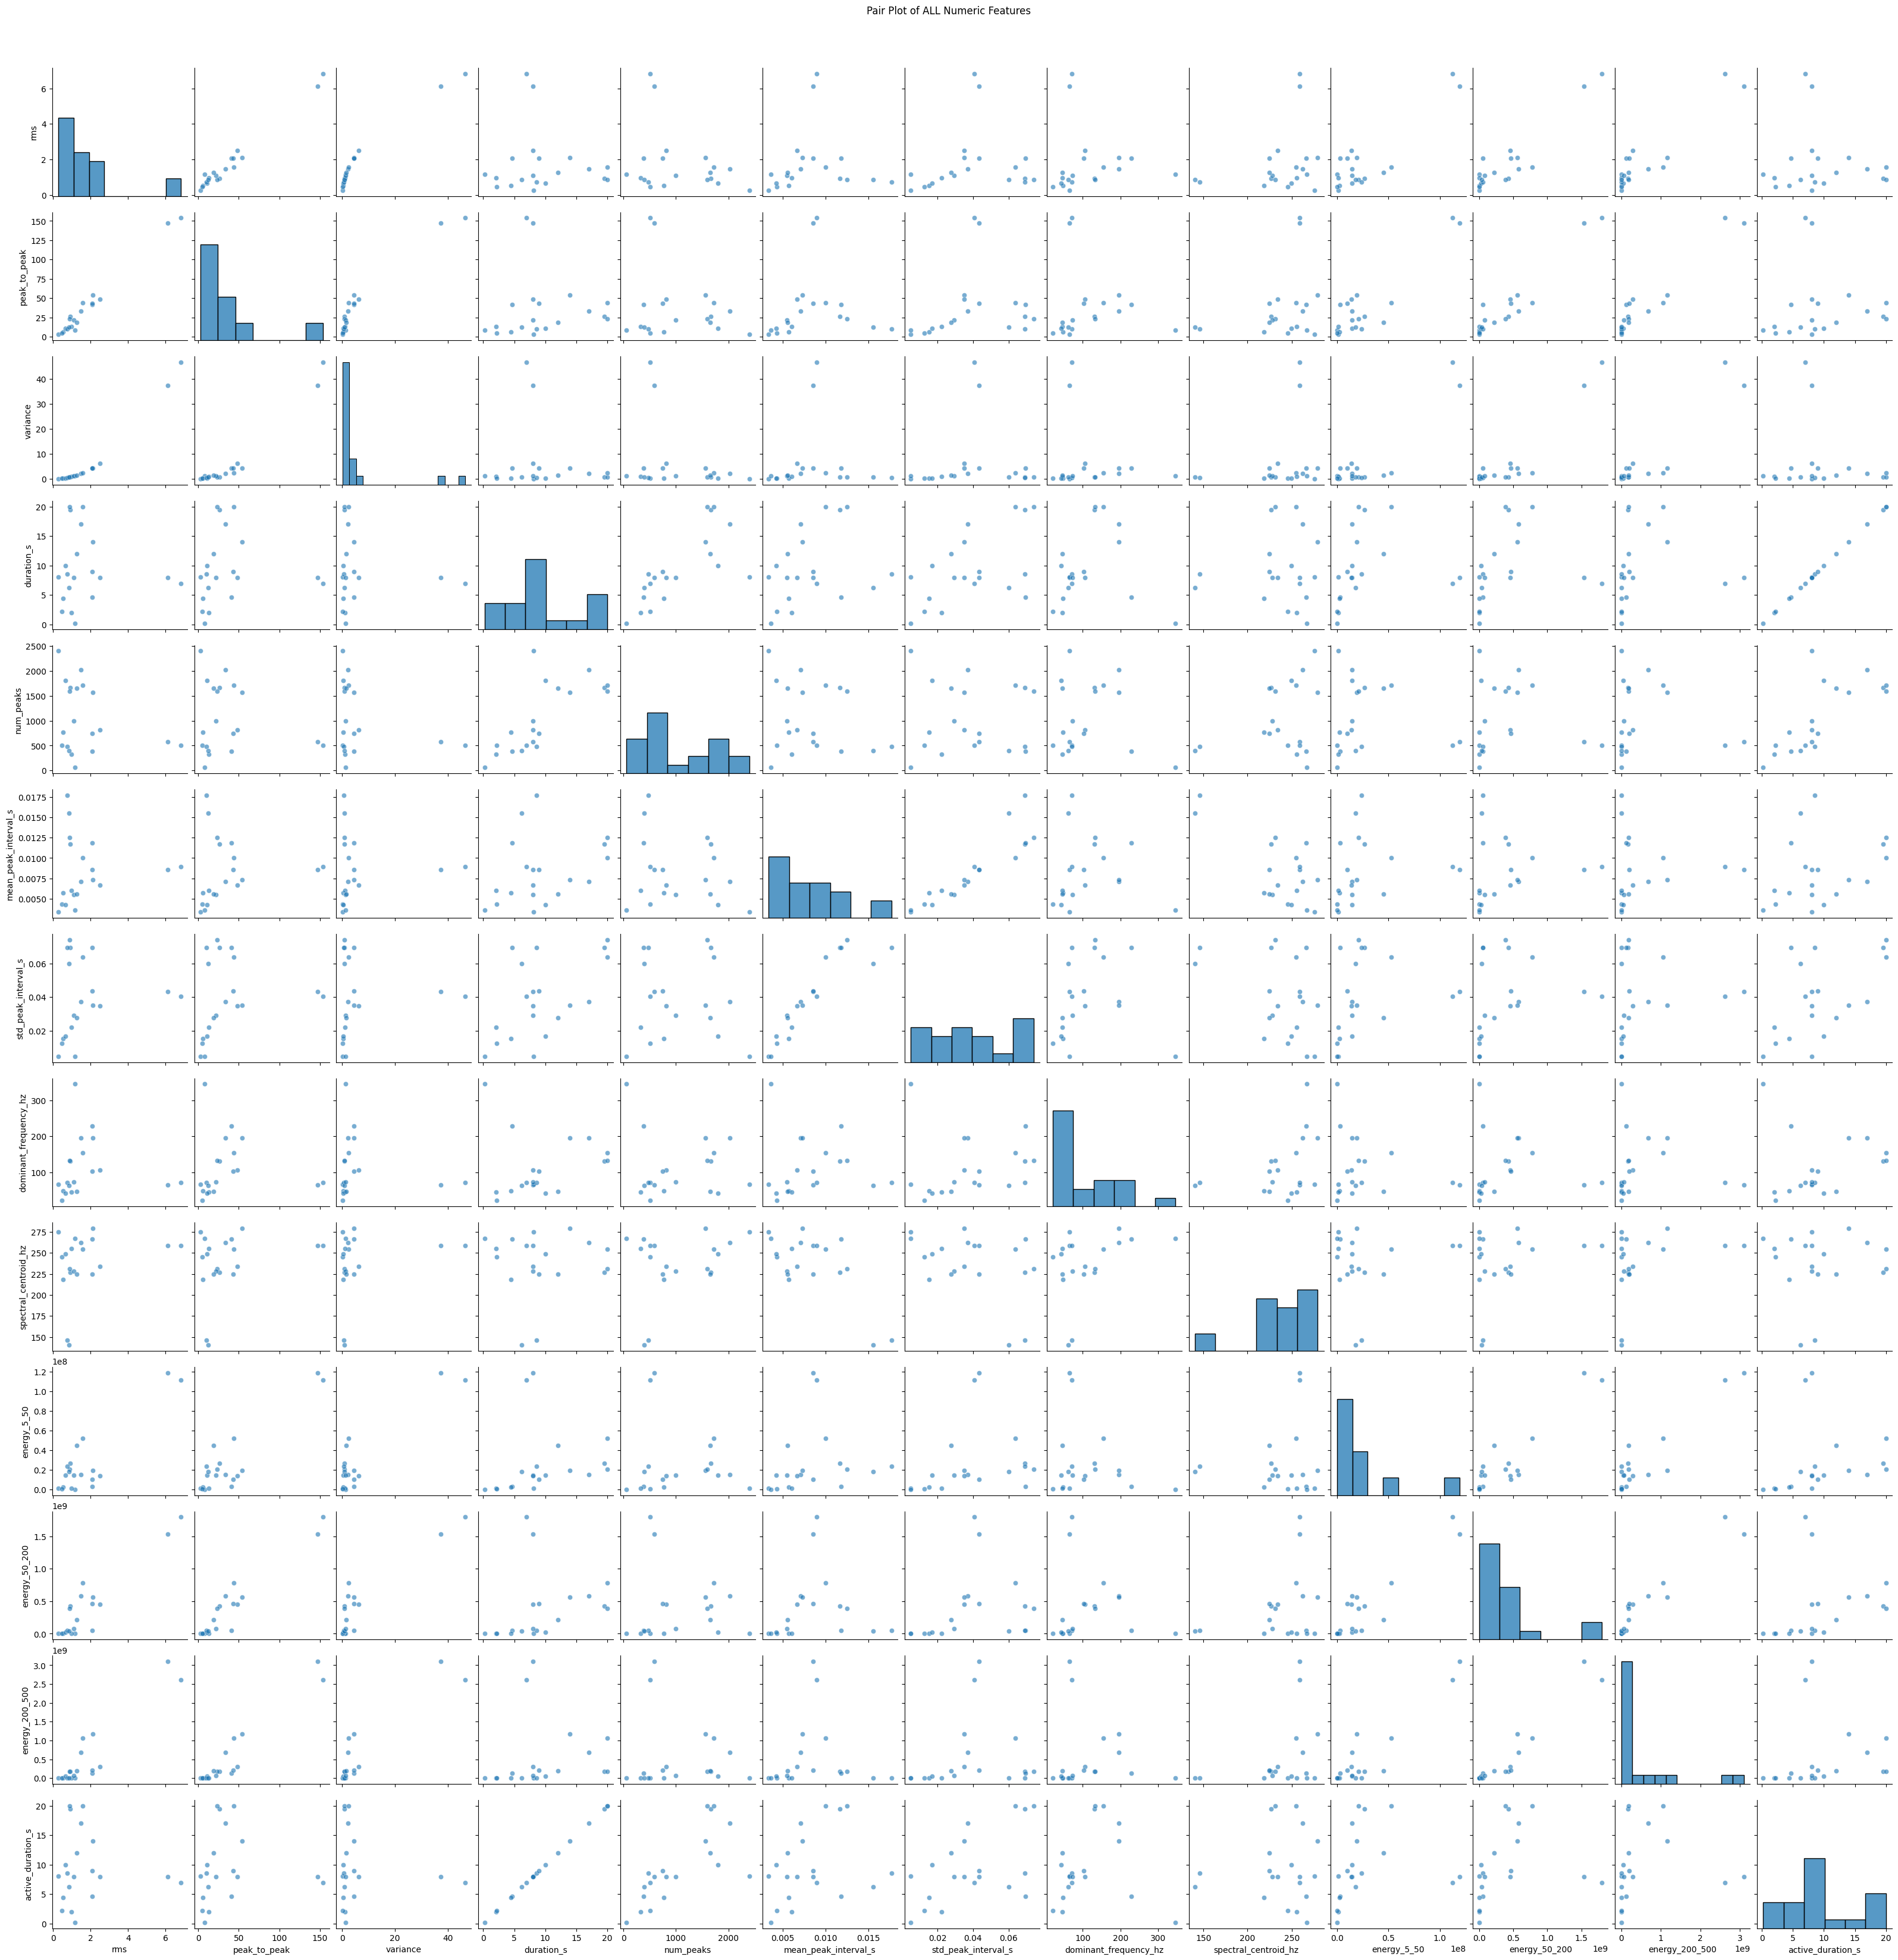

In [47]:
# =========================
# Pair plot for ALL numeric features
# =========================
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select all numeric columns only
plot_df = features_df.select_dtypes(include=[np.number]).copy()

# Drop rows with NaNs (pairplot cannot handle NaNs)
plot_df = plot_df.dropna()

print("Number of features in pair plot:", plot_df.shape[1])
print("Feature names:")
print(plot_df.columns.tolist())

# Create pair plot
sns.pairplot(
    plot_df,
    diag_kind="hist",
    plot_kws={"alpha": 0.6, "s": 35}
)

plt.suptitle("Pair Plot of ALL Numeric Features", y=1.02)
plt.show()


## 7) Feature visualization

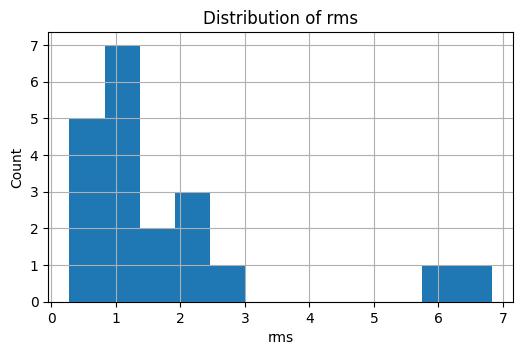

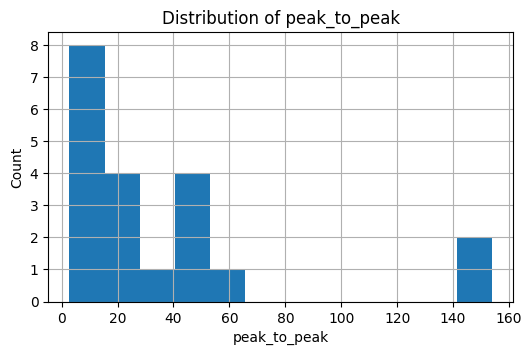

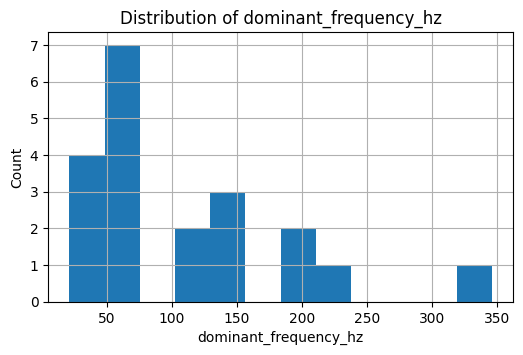

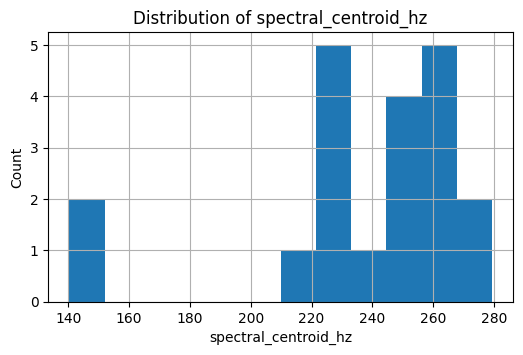

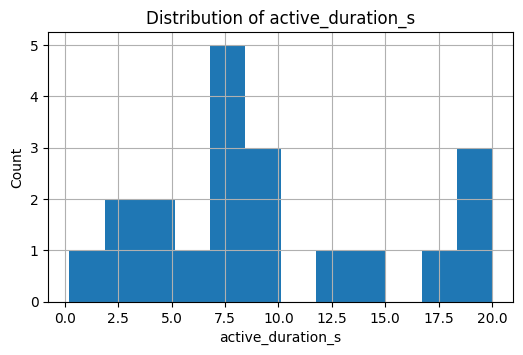

In [48]:

key_feats = ["rms", "peak_to_peak", "dominant_frequency_hz", "spectral_centroid_hz", "active_duration_s"]
for feat in key_feats:
    plt.figure(figsize=(6,3.5))
    plt.hist(features_df[feat].dropna(), bins=12)
    plt.xlabel(feat)
    plt.ylabel("Count")
    plt.title(f"Distribution of {feat}")
    plt.grid(True)
    plt.show()


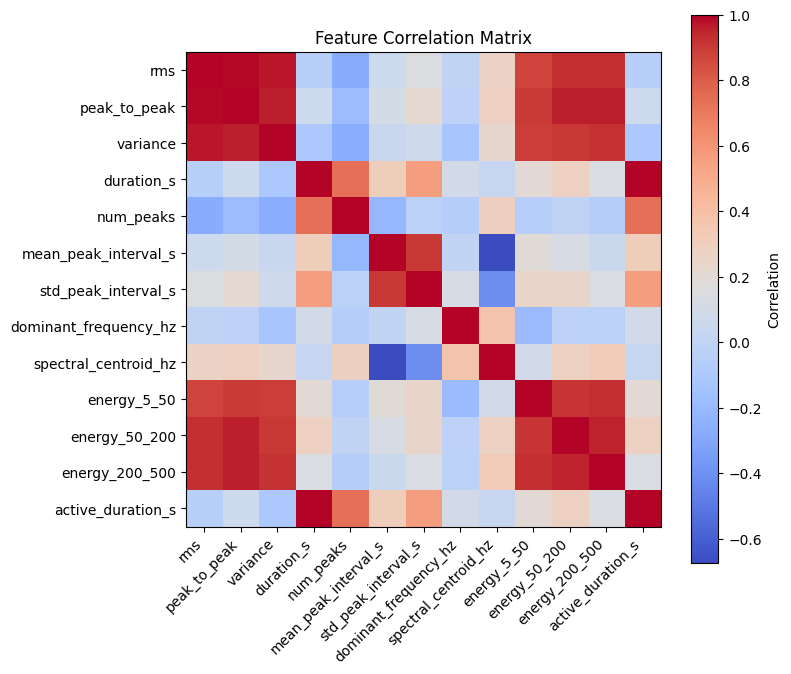

In [49]:

num_df = features_df.select_dtypes(include=[np.number]).copy()
corr = num_df.corr()

plt.figure(figsize=(8,7))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## 8) Clustering (2 clusters) + PCA

In [50]:

X = features_df.select_dtypes(include=[np.number]).copy()
X = X.fillna(X.mean(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

features_df["cluster"] = clusters
features_df[["cluster"]].value_counts().sort_index()


cluster
0          18
1           2
Name: count, dtype: int64

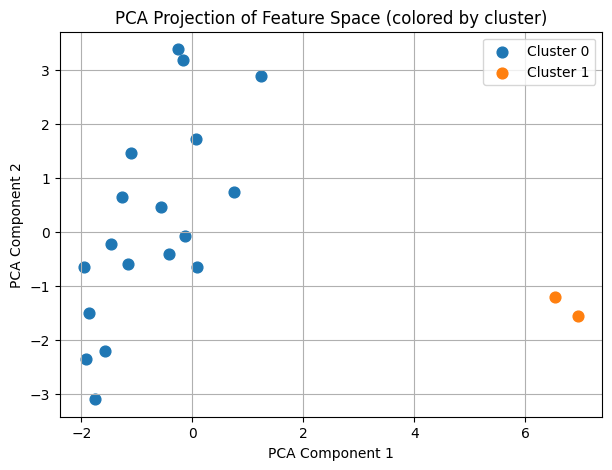

Explained variance ratio: [0.4484441  0.24448266]


In [51]:

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
for c in sorted(np.unique(clusters)):
    m = clusters == c
    plt.scatter(X_pca[m, 0], X_pca[m, 1], label=f"Cluster {c}", s=60)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Projection of Feature Space (colored by cluster)")
plt.legend()
plt.grid(True)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


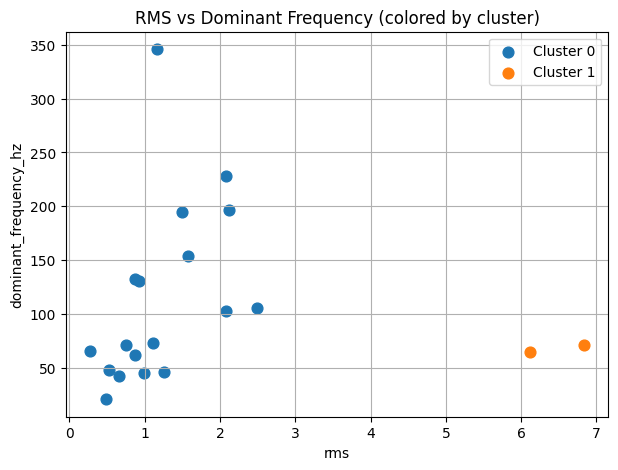

In [52]:

plt.figure(figsize=(7,5))
for c in sorted(features_df["cluster"].unique()):
    sub = features_df[features_df["cluster"] == c]
    plt.scatter(sub["rms"], sub["dominant_frequency_hz"], label=f"Cluster {c}", s=60)

plt.xlabel("rms")
plt.ylabel("dominant_frequency_hz")
plt.title("RMS vs Dominant Frequency (colored by cluster)")
plt.legend()
plt.grid(True)
plt.show()


## 9) Cluster summaries + mapping clusters to timestamps

In [53]:

summary_cols = ["rms", "peak_to_peak", "dominant_frequency_hz", "spectral_centroid_hz",
                "active_duration_s", "num_peaks", "mean_peak_interval_s"]

cluster_summary = features_df.groupby("cluster")[summary_cols].agg(["mean", "std", "min", "max"])
cluster_summary


rms                               peak_to_peak             \
             mean       std       min       max         mean        std   
cluster                                                                   
0        1.206342  0.640797  0.279406  2.497618    23.482212  16.635127   
1        6.474478  0.501915  6.119571  6.829386   150.617901   4.675951   

                                dominant_frequency_hz             ...  \
                min         max                  mean        std  ...   
cluster                                                           ...   
0          2.739692   53.790225            114.917188  83.416493  ...   
1        147.311505  153.924298             68.544643   4.482552  ...   

        active_duration_s          num_peaks                         \
                      min   max         mean         std  min   max   
cluster                                                               
0                   0.214  20.0  1105.611111  696.182544   59  2399   
1                   7.000   8.0   546.500000   51.618795  510   583   

        mean_peak_interval_s                               
                        mean      std       min       max  
cluster                                                    
0                   0.008185  0.00418  0.003368  0.017718  
1                   0.008752  0.00027  0.008562  0.008943  

[2 rows x 28 columns]

In [54]:

combined = meta_df.join(features_df[["cluster"]])
combined.sort_values(["date", "time", "sensor_id"])


,date,time,sensor_id,deployment_id,channel_id,n_samples,duration_s,cluster
file,,,,,,,,
20220507_131544_065205_001_channel1.bin,20220507,131544,065205,001,1,16000,8.0,1
20220507_131853_065205_001_channel1.bin,20220507,131853,065205,001,1,14000,7.0,1
20220509_091022_031264_001_channel1.bin,20220509,091022,031264,001,1,34000,17.0,0
20220509_094934_031264_001_channel1.bin,20220509,094934,031264,001,1,28000,14.0,0
20220509_095320_031157_001_channel1.bin,20220509,095320,031157,001,1,50000,25.0,0
20220509_100254_031157_001_channel1.bin,20220509,100254,031157,001,1,52000,26.0,0
20220509_104538_095913_001_channel1.bin,20220509,104538,095913,001,1,44000,22.0,0
20220509_105854_095913_001_channel1.bin,20220509,105854,095913,001,1,40000,20.0,0
20220511_110903_077531_001_channel1.bin,20220511,110903,077531,001,1,24000,12.0,0



## 10) Interpretation notes and limitations (task-aligned)

### What we can say from the data
- Train passages are clearly visible in time domain and RMS envelope  
- Filtering improves signal-to-noise while preserving physical impacts  
- Extracted features (energy, timing, spectral content) capture meaningful differences  
- Unsupervised clustering provides a plausible grouping into 2 passage-related clusters

### What we cannot uniquely determine (no ground truth)
- Exact train type  
- Exact speed (km/h)  
- Exact axle geometry  

### Next steps in a real project
- Obtain ground truth labels for train type and speed  
- Use multi-sensor time-of-flight for direct speed estimation  
- Expand feature set (spectrogram / wavelets / band power per window)  
- Evaluate clustering stability + supervised models once labels exist
